In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------
# Model (Graph-level)
# -------------------------
class PatientGraphGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, dropout=0.4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = torch.cat([global_mean_pool(x, data.batch), global_max_pool(x, data.batch)], dim=-1)
        return self.mlp(g).squeeze(-1)


# -------------------------
# Utilities: metrics + threshold
# -------------------------
@torch.no_grad()
def collect_logits_and_labels(model, loader):
    model.eval()
    logits_all, y_all = [], []
    for batch in loader:
        batch = batch.to(device)
        logits_all.append(model(batch).detach().cpu())
        y_all.append(batch.y.view(-1).detach().cpu().long())
    return torch.cat(logits_all), torch.cat(y_all)

def metrics_at_threshold(probs, y_true, thr):
    preds = (probs >= thr).long()
    tp = int(((preds == 1) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    bal_acc = 0.5 * (tpr + tnr)

    prec = tp / max(tp + fp, 1)
    f1 = (2 * prec * tpr) / max(prec + tpr, 1e-12)

    # AUROC via ranks (small-N friendly)
    y_np = y_true.numpy()
    if len(set(y_np.tolist())) < 2:
        auroc = float("nan")
    else:
        p = probs.numpy()
        order = np.argsort(p)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(p)) + 1
        pos_ranks_sum = ranks[y_np == 1].sum()
        n_pos = (y_np == 1).sum()
        n_neg = (y_np == 0).sum()
        auroc = (pos_ranks_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

    return {"acc": acc, "bal_acc": bal_acc, "f1": f1, "auroc": auroc,
            "tp": tp, "tn": tn, "fp": fp, "fn": fn}

def find_best_threshold(probs, y_true, objective="bal_acc"):
    thrs = np.linspace(0.05, 0.95, 181)
    best_thr, best_val, best_m = 0.5, -1.0, None
    for t in thrs:
        m = metrics_at_threshold(probs, y_true, float(t))
        if m[objective] > best_val:
            best_val, best_thr, best_m = m[objective], float(t), m
    return best_thr, best_m


# -------------------------
# Stratified K-Fold split (no sklearn)
# -------------------------
def stratified_kfold_indices(y, k=5, seed=42):
    """
    y: list[int] 0/1
    returns: list of (train_idx, test_idx)
    """
    rng = np.random.default_rng(seed)
    y = np.array(y, dtype=int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    folds0 = np.array_split(idx0, k)
    folds1 = np.array_split(idx1, k)

    splits = []
    for i in range(k):
        test_idx = np.concatenate([folds0[i], folds1[i]])
        train_idx = np.concatenate([np.concatenate([folds0[j] for j in range(k) if j != i]),
                                    np.concatenate([folds1[j] for j in range(k) if j != i])])
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)
        splits.append((train_idx.tolist(), test_idx.tolist()))
    return splits


# -------------------------
# Balanced sampler
# -------------------------
def make_balanced_sampler(graphs):
    ys = [int(g.y.view(-1)[0].item()) for g in graphs]
    n0 = sum(y == 0 for y in ys)
    n1 = sum(y == 1 for y in ys)
    w0 = 1.0 / max(n0, 1)
    w1 = 1.0 / max(n1, 1)
    weights = [w1 if y == 1 else w0 for y in ys]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


# -------------------------
# K-Fold training
# -------------------------
def run_kfold_cv(
    graphs,
    k=5,
    seed=42,
    epochs=200,
    patience=25,
    batch_size=8,
    lr=5e-4,
    weight_decay=5e-4,
    hidden_dim=64,
    num_layers=2,
    dropout=0.4,
    threshold_objective="bal_acc",  # or "f1"
    use_balanced_sampler=True,
):
    ys = [int(g.y.view(-1)[0].item()) for g in graphs]
    splits = stratified_kfold_indices(ys, k=k, seed=seed)

    in_dim = graphs[0].x.size(-1)

    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        # Build train/test sets
        train_set = [graphs[i] for i in train_idx]
        test_set  = [graphs[i] for i in test_idx]

        # Further split train into train/val (stratified) for early stopping + threshold tuning
        y_train = [int(g.y.view(-1)[0].item()) for g in train_set]
        inner_splits = stratified_kfold_indices(y_train, k=5, seed=seed + fold)
        inner_train_idx, val_idx = inner_splits[0]  # take first split as val
        inner_train_set = [train_set[i] for i in inner_train_idx]
        val_set = [train_set[i] for i in val_idx]

        # pos_weight from inner_train only
        y_it = torch.tensor([int(g.y.view(-1)[0].item()) for g in inner_train_set], dtype=torch.long)
        n_pos = int((y_it == 1).sum().item())
        n_neg = int((y_it == 0).sum().item())
        pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device, dtype=torch.float32)

        # Loaders
        if use_balanced_sampler:
            sampler = make_balanced_sampler(inner_train_set)
            train_loader = DataLoader(inner_train_set, batch_size=batch_size, sampler=sampler)
        else:
            train_loader = DataLoader(inner_train_set, batch_size=batch_size, shuffle=True)

        val_loader  = DataLoader(val_set, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

        # Model
        model = PatientGraphGNN(in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout).to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        best_state = None
        best_val_obj = -1.0
        best_thr = 0.5
        no_improve = 0

        for ep in range(1, epochs + 1):
            model.train()
            for batch in train_loader:
                batch = batch.to(device)
                opt.zero_grad()
                logits = model(batch)
                yb = batch.y.view(-1).float()
                loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                opt.step()

            # ---- Validation: tune threshold on val each epoch ----
            val_logits, val_y = collect_logits_and_labels(model, val_loader)
            val_probs = torch.sigmoid(val_logits)
            thr, thr_metrics = find_best_threshold(val_probs, val_y, objective=threshold_objective)

            val_obj = thr_metrics[threshold_objective]
            if val_obj > best_val_obj:
                best_val_obj = val_obj
                best_thr = thr
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

        # Restore best
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

        # Final eval on test fold using best_thr from val
        test_logits, test_y = collect_logits_and_labels(model, test_loader)
        test_probs = torch.sigmoid(test_logits)

        test_metrics = metrics_at_threshold(test_probs, test_y, best_thr)
        test_metrics["best_thr"] = best_thr
        test_metrics["test_probs"] = test_probs.numpy()
        test_metrics["test_y"] = test_y.numpy()

        fold_results.append(test_metrics)

        # Print fold summary
        n_test_pos = int((test_y == 1).sum().item())
        n_test_neg = int((test_y == 0).sum().item())
        print(
            f"Fold {fold}/{k} | test (pos={n_test_pos}, neg={n_test_neg}) "
            f"| thr={best_thr:.3f} | acc={test_metrics['acc']:.3f} "
            f"| bal_acc={test_metrics['bal_acc']:.3f} | f1={test_metrics['f1']:.3f} "
            f"| auroc={test_metrics['auroc']:.3f} | tp={test_metrics['tp']} tn={test_metrics['tn']} "
            f"fp={test_metrics['fp']} fn={test_metrics['fn']}"
        )

    # Aggregate
    def mean_std(key):
        vals = [r[key] for r in fold_results if not (isinstance(r[key], float) and np.isnan(r[key]))]
        return float(np.mean(vals)), float(np.std(vals))

    print("\n===== 5-FOLD SUMMARY (mean ± std) =====")
    for key in ["acc", "bal_acc", "f1", "auroc"]:
        m, s = mean_std(key)
        print(f"{key:8s}: {m:.3f} ± {s:.3f}")

    # Also show thresholds
    thrs = [r["best_thr"] for r in fold_results]
    print(f"best_thr : {float(np.mean(thrs)):.3f} ± {float(np.std(thrs)):.3f}")

    return fold_results, model



In [5]:
import os
import glob
import torch
from torch_geometric.data import Data

def load_graphs_and_tables(graph_dir: str):
    """
    Loads .pt files saved as: torch.save((graph, table), path)
    Returns:
      graphs: list[Data]
      tables: list[object]  (often pandas.DataFrame)
      paths:  list[str]
    """
    paths = sorted(glob.glob(os.path.join(graph_dir, "*.pt")))
    if not paths:
        raise FileNotFoundError(f"No .pt files found in: {graph_dir}")

    graphs, tables, used_paths = [], [], []
    for p in paths:
        graph, table = torch.load(p, map_location="cpu", weights_only=False)
        if not isinstance(graph, Data):
            raise TypeError(f"{p}: first element is {type(graph)}, expected torch_geometric.data.Data")
        graphs.append(graph)
        tables.append(table)
        used_paths.append(p)

    print(f"Loaded {len(graphs)} (graph, table) pairs from {graph_dir}")
    return graphs, tables, used_paths


In [6]:
downsample_size = 10000
graphs, tables, used_paths = load_graphs_and_tables(f"/dsi/efroni-lab/sbm/chen2/graph_data/ovarian/{downsample_size}/0.08_True_True/")
results, model = run_kfold_cv(
    graphs,
    k=5,
    seed=42,
    epochs=200,
    patience=25,
    batch_size=8,
    lr=5e-4,
    weight_decay=5e-4,
    hidden_dim=64,
    num_layers=2,
    dropout=0.4,
    threshold_objective="bal_acc",
    use_balanced_sampler=True,
)

Loaded 82 (graph, table) pairs from /dsi/efroni-lab/sbm/chen2/graph_data/ovarian/10000/0.08_True_True/


/home/dsi/chenbis/anaconda3/envs/chephy2/lib/python3.10/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Fold 1/5 | test (pos=7, neg=10) | thr=0.530 | acc=0.647 | bal_acc=0.657 | f1=0.625 | auroc=0.629 | tp=5 tn=6 fp=4 fn=2
Fold 2/5 | test (pos=7, neg=10) | thr=0.535 | acc=0.412 | bal_acc=0.414 | f1=0.375 | auroc=0.457 | tp=3 tn=4 fp=6 fn=4
Fold 3/5 | test (pos=7, neg=10) | thr=0.525 | acc=0.353 | bal_acc=0.429 | f1=0.522 | auroc=0.386 | tp=6 tn=0 fp=10 fn=1
Fold 4/5 | test (pos=7, neg=9) | thr=0.050 | acc=0.438 | bal_acc=0.500 | f1=0.609 | auroc=0.413 | tp=7 tn=0 fp=9 fn=0
Fold 5/5 | test (pos=6, neg=9) | thr=0.530 | acc=0.400 | bal_acc=0.472 | f1=0.526 | auroc=0.333 | tp=5 tn=1 fp=8 fn=1

===== 5-FOLD SUMMARY (mean ± std) =====
acc     : 0.450 ± 0.102
bal_acc : 0.494 ± 0.087
f1      : 0.531 ± 0.089
auroc   : 0.443 ± 0.101
best_thr : 0.434 ± 0.192


In [7]:
import torch

def topk_cdr3_contributors_gradxinput(model, data, k=20, use_abs=True):
    """
    Returns top-k (cdr3, score, node_idx) for a single graph.
    Score is per-node attribution based on Grad×Input on the logit.
    """
    model.eval()
    data = data.to(next(model.parameters()).device)

    # Enable grads on node features
    x = data.x.detach().clone().requires_grad_(True)
    data = data.clone()
    data.x = x

    # Forward (logit; do NOT sigmoid for gradients)
    logit = model(data).view(-1)[0]
    model.zero_grad()
    logit.backward()

    # Node attribution
    contrib = x.grad * x                     # [N, D]
    node_scores = contrib.abs().sum(dim=1) if use_abs else contrib.sum(dim=1)  # [N]

    topk_idx = torch.topk(node_scores, k=min(k, node_scores.numel())).indices.tolist()
    topk_scores = node_scores[topk_idx].detach().cpu().tolist()

    # Map back to CDR3 strings (requires the metadata line in build_graph)
    node_seqs = getattr(data, "node_seqs", None)
    if node_seqs is None:
        return list(zip(topk_idx, topk_scores))

    return [(node_seqs[i], s, i) for i, s in zip(topk_idx, topk_scores)]

In [8]:
g = graphs[0].to(device)
for g in graphs:
    g = g.to(device)
    top = topk_cdr3_contributors_gradxinput(model, g, k=30)
    for cdr3, score, idx in top[:10]:
        print(idx, score, cdr3)
    print()


4279 0.029104173183441162 CASSSSSASSDLGELFF
8077 0.028682727366685867 CASSHPQMQPLLSNQPQHF
6595 0.02590424194931984 CASRPDRGSQPQHF
6651 0.0226515531539917 CASSASSDPFF
1414 0.022102387621998787 CASSMGGGSTSPQYF
5681 0.021353818476200104 CASSRDSGTSDQPQHF
3129 0.0191325880587101 CASSPRQVPLPKLFF
1004 0.018966112285852432 CSARDQARGSNQPQHF
2101 0.018190378323197365 CASSQDSPLHF
4693 0.0139250997453928 CATSGQGTGGPFSSYNEQFF

3847 0.041580598801374435 CASSPPSGDSLF
2144 0.024600857868790627 CASSTSSRDSSF
7156 0.023644249886274338 CASSPQPSSGSDTQYF
6139 0.020062394440174103 CASSQGQVSEQFF
2549 0.01787153072655201 CASRSGGTGGQPQHF
5016 0.01725905016064644 CASSFSLSHPFF
7049 0.01573919877409935 CATAIPHQPQHF
6582 0.014002615585923195 CASRSRASNNSPLHF
903 0.013860607519745827 CASSPPRAASSSHF
7423 0.013588120229542255 CASSNPRDRADRGSYEQYF

3870 0.028717195615172386 CASSRVGGSGGSEQFF
2641 0.024918321520090103 CASSKFCSSSSYNEQFF
7338 0.022810503840446472 CASSLARVWASGRSHPTAF
3220 0.019023537635803223 CASSWETGPSTDTQYF

In [9]:
import json
import pickle

# Save results to JSON (metrics only, without numpy arrays)
results_json = []
for r in results:
    r_json = {k: v for k, v in r.items() if k not in ["test_probs", "test_y"]}
    results_json.append(r_json)

with open("cv_results_metrics.json", "w") as f:
    json.dump(results_json, f, indent=2)

# Save full results (including arrays) as pickle
with open("cv_results_full.pkl", "wb") as f:
    pickle.dump(results, f)

print("Results saved to cv_results_metrics.json and cv_results_full.pkl")

# Create loader functions
def load_results_json(filepath="cv_results_metrics.json"):
    """Load metrics from JSON file"""
    with open(filepath, "r") as f:
        return json.load(f)

def load_results_full(filepath="cv_results_full.pkl"):
    """Load full results (with test_probs and test_y) from pickle file"""
    with open(filepath, "rb") as f:
        return pickle.load(f)

# Test the loaders
loaded_results = load_results_full()
print(f"Loaded {len(loaded_results)} fold results from pickle")

Results saved to cv_results_metrics.json and cv_results_full.pkl
Loaded 5 fold results from pickle


/tmp/ipykernel_4068798/81220954.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=metrics, showmeans=True)


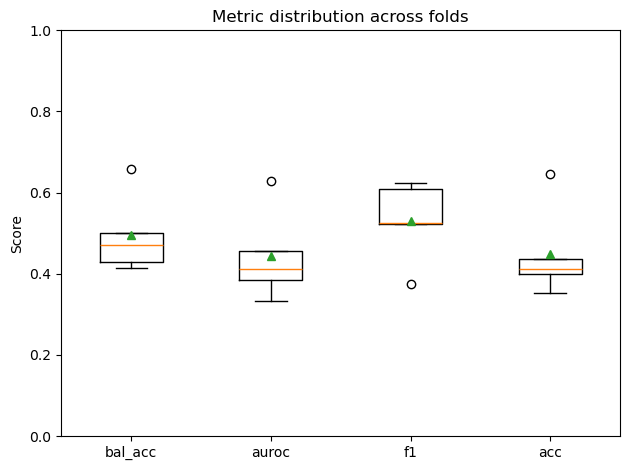

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metric_boxplots(results, metrics=("bal_acc", "auroc", "f1", "acc"), title="Metric distribution across folds"):
    data = [np.array([r[m] for r in results], dtype=float) for m in metrics]

    plt.figure()
    plt.boxplot(data, labels=metrics, showmeans=True)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_metric_boxplots(results)


/tmp/ipykernel_4068798/2784462474.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True)


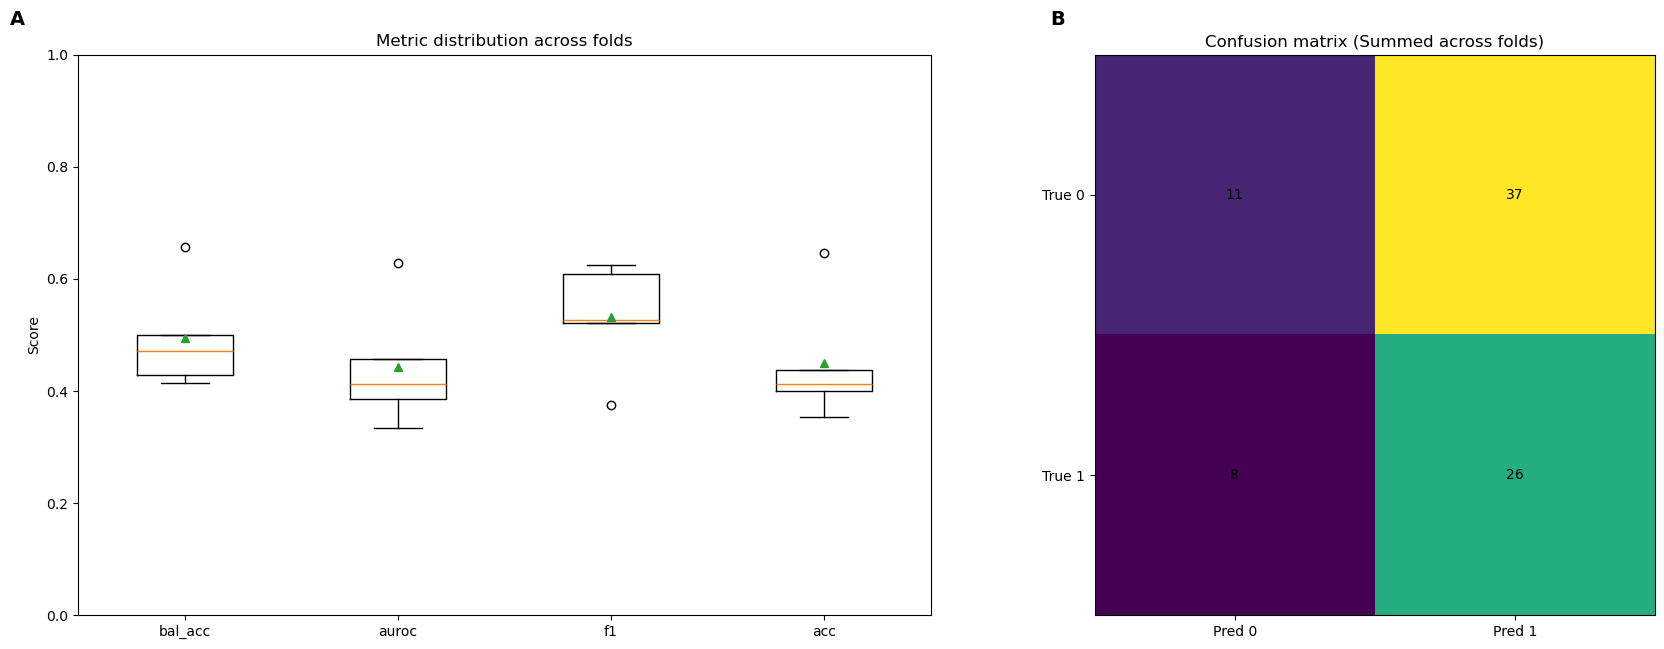

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

def add_panel_labels(axes, labels=("A", "B")):
    for ax, lab in zip(axes.flat, labels):
        ax.text(
            -0.08, 1.08, lab,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
            ha="left"
        )

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)


ax = axes[0, 0]
metrics=("bal_acc", "auroc", "f1", "acc")
title="Metric distribution across folds"
data = [np.array([r[m] for r in results], dtype=float) for m in metrics]

ax.boxplot(data, labels=metrics, showmeans=True)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title(title)

ax = axes[0, 1]
title_prefix="Confusion matrix"

# overall summed
tn = sum(r["tn"] for r in results)
fp = sum(r["fp"] for r in results)
fn = sum(r["fn"] for r in results)
tp = sum(r["tp"] for r in results)
cm_all = np.array([[tn, fp],
                    [fn, tp]], dtype=int)

ax.imshow(cm_all, interpolation="nearest")
ax.set_title(f"{title_prefix} (Summed across folds)")
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["True 0", "True 1"])
for (y, x), val in np.ndenumerate(cm_all):
    ax.text(x, y, str(val), ha="center", va="center")
# ax.colorbar()




fig.delaxes(axes[1, 1])
fig.delaxes(axes[1, 0])

add_panel_labels(axes[:1], labels=("A", "B"))
plt.show()
